In [210]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [226]:
# LinearRegressionModel (scratch __version__)
# Formula: y = a + bx
# a: bias (intercepter)
# b: weight (slope)
# x: imaginary number

weight = 0.7
bias = 0.3

# PyTorch RandomSeed
torch.manual_seed(42)

X = torch.arange(0, 10, 0.1).unsqueeze(dim=1)
y = bias + weight * X

In [227]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

len(X_train), len(X_test), len(y_train), len(y_test)

(80, 20, 80, 20)

In [228]:
# LinearRegressionModel (PyTorch __version__)

class LinearRegressionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = torch.nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))
        self.bias = torch.nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.bias + self.weights * x

In [229]:
model = LinearRegressionModel()

In [230]:
with torch.inference_mode():
    y_pred = model(X_train)

In [231]:
X_train.shape, y_train.shape

(torch.Size([80, 1]), torch.Size([80, 1]))

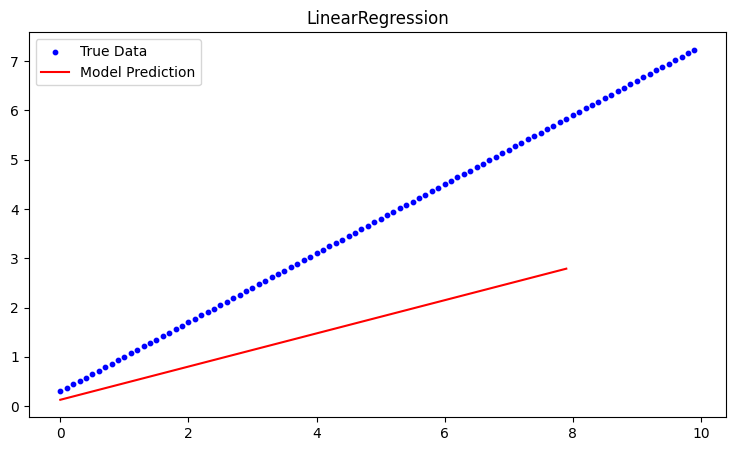

In [232]:
plt.figure(figsize=(9, 5))
plt.title("LinearRegression")
plt.scatter(X, y, label="True Data", c="blue", s=10)
plt.plot(X_train, y_pred, label="Model Prediction", c="red")
plt.legend()
plt.show()

In [233]:
## Loss Function & Optimizer

# L1Loss func
loss_func = torch.nn.L1Loss()

# Optimizer

optimizer = torch.optim.SGD(params = model.parameters(),
                           lr=0.001)

Epoch: 000 | Loss: 1.5730587244033813 | Test Loss: 3.3137543201446533
Epoch: 010 | Loss: 1.4070336818695068 | Test Loss: 2.9502291679382324
Epoch: 020 | Loss: 1.2410085201263428 | Test Loss: 2.5867044925689697
Epoch: 030 | Loss: 1.0749835968017578 | Test Loss: 2.223179578781128
Epoch: 040 | Loss: 0.9089586138725281 | Test Loss: 1.859654188156128
Epoch: 050 | Loss: 0.7429336309432983 | Test Loss: 1.4961295127868652
Epoch: 060 | Loss: 0.5769085884094238 | Test Loss: 1.1326043605804443
Epoch: 070 | Loss: 0.4108835756778717 | Test Loss: 0.7690795063972473
Epoch: 080 | Loss: 0.2448585480451584 | Test Loss: 0.4055543839931488
Epoch: 090 | Loss: 0.07883352786302567 | Test Loss: 0.042029570788145065


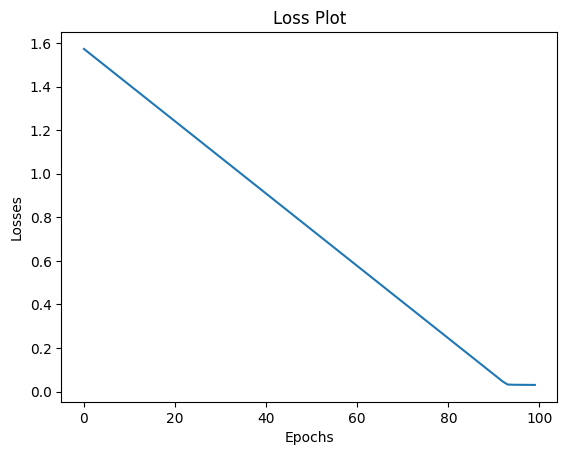

In [236]:
torch.manual_seed(42)

epochs = 100
losses = []

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = loss_func(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    with torch.inference_mode():
        y_test_pred = model(X_test)

        test_loss = loss_func(y_test_pred, y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch:03d} | Loss: {loss.item()} | Test Loss: {test_loss.item()}")

plt.title("Loss Plot")
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.show()

In [237]:
model.state_dict()

OrderedDict([('weights', tensor([0.7131])), ('bias', tensor([0.2269]))])

In [238]:
weight, bias

(0.7, 0.3)

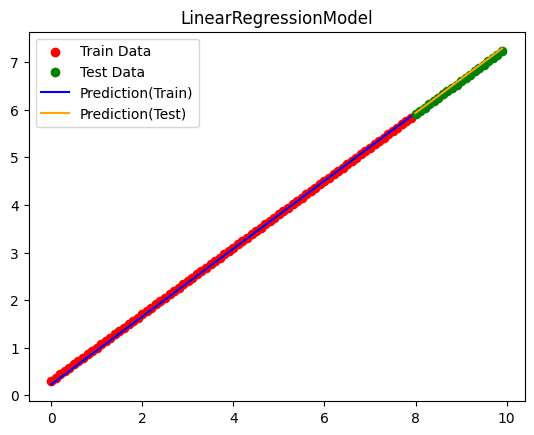

In [239]:
with torch.inference_mode():
    y_pred_train = model(X_train)
    y_pred_test = model(X_test)

plt.title("LinearRegressionModel")
plt.scatter(X_train, y_train, label="Train Data", color="red")
plt.scatter(X_test, y_test, label="Test Data", color="green")
plt.plot(X_train, y_pred_train, label="Prediction(Train)", color="Blue")
plt.plot(X_test, y_pred_test, label="Prediction(Test)", color="orange")
plt.legend()
plt.show()